<a href="https://colab.research.google.com/github/KarlyHdzC/Mineria_de_datos/blob/main/Miner%C3%ADa_de_datos_07_Mi_primera_red_neuronal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Minería de Datos - Universidad Anáhuac
## Machine Learning - Libreta 7
**Profesor: Dr. Farid Krayem Pineda**

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [58]:
# Lista de kilogramos
kilogramos = np.array([43, 27, 75, 86, 99, 14, 63, 47, 74, 72, 78, 97, 64, 52, 84, 10, 20, 21, 55, 56], dtype=float)

# Lista de libras
libras = np.array([94.80, 59.52, 165.35, 189.60, 218.26, 30.86, 138.89, 103.62, 163.14, 158.73, 171.96, 213.85, 141.10, 114.64, 185.19, 22.05, 44.09, 46.30, 121.25, 123.46], dtype=float)


In [77]:
# Aquí se define la arquitectura de la red neuronal
# Entrada (1) → [3 neuronas] → [3 neuronas] → [1 neurona]

oculta1 = tf.keras.layers.Dense(units=3, input_shape=[1])
oculta2 = tf.keras.layers.Dense(units=3)
salida = tf.keras.layers.Dense(units=1)
modelo = tf.keras.Sequential([oculta1, oculta2, salida])

In [78]:
# Adam es un algortimo que optimiza los pesos ajustando gradientes
# 0.1 es como se mueve el learning rate, muy pequeño aprende lento, muy grande puede no ser óptimo
# Mean squared mide el error entre lo que mide el modelo y la realidad

modelo.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='mean_squared_error'
)

In [79]:
print("Comenzando entrenamiento...")
# kilogramos: Datos de entrada (X), es decir, lo que el modelo usará para hacer predicciones.
# libras:Datos de salida (y), lo que el modelo debe aprender a predecir a partir de los kilogramos.

historial = modelo.fit(kilogramos, libras, epochs=1000, verbose=True) # Si no quieres ver las acciones se establece en false.
print("Modelo entrenado!")

Comenzando entrenamiento...
Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 17033.5742
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 16936.9375
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - loss: 16840.5059
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 16744.2871
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 16648.2793
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 16552.4883
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 16456.9199
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - loss: 16361.5752
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 16266.4551
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 16171.5674
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 16076.9092
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 15982.4873
Epoch 13/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 15888.3018
Epoch 14/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - l

¿Qué es historial.history["loss"]?
historial es el objeto devuelto por modelo.fit(...).

.history es un diccionario que guarda el historial del entrenamiento.

"loss" contiene una lista con los valores de pérdida en cada época.

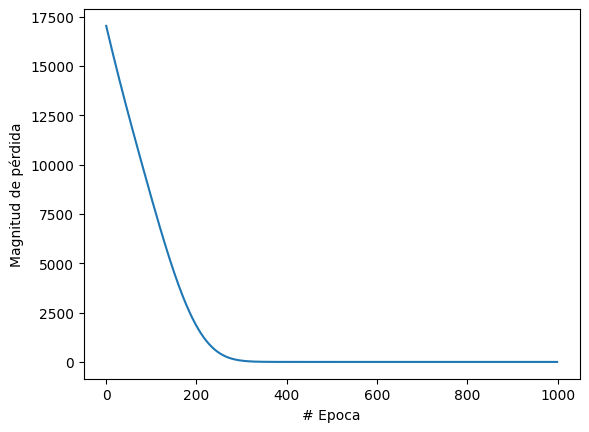

In [80]:
## Gráficamos cuántas épocas le tomo al modelo poder entrenarse ##
import matplotlib.pyplot as plt
plt.xlabel("# Epoca")
plt.ylabel("Magnitud de pérdida")
plt.plot(historial.history["loss"])

#### ✅ ¿Qué está pasando aquí?

- `modelo.predict(...)` usa el modelo ya entrenado para **predecir valores de salida** a partir de nuevas entradas.
- `np.array([100, 66])`:
  - Es un arreglo con dos valores en kilogramos (100 kg y 66 kg).
  - El modelo los convierte en libras, aprendiendo de los datos previos.



In [81]:
print("Hagamos una predicción!")
entrada = np.array([100, 66, 150])
resultado = modelo.predict(entrada)

for i in range(len(entrada)):
    print(f"{entrada[i]} kg son aproximadamente {resultado[i][0]:.2f} libras")


Hagamos una predicción!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
100 kg son aproximadamente 219.98 libras
66 kg son aproximadamente 145.56 libras
150 kg son aproximadamente 329.43 libras


✅ ¿Qué hace?
Usa los mismos datos de entrenamiento (kilogramos, libras) para evaluar el rendimiento del modelo.

Calcula el valor de la función de pérdida que definimos antes (mean_squared_error).

Devuelve un solo número: el error cuadrático medio (MSE).

⚠️ Como estamos usando los mismos datos de entrenamiento, no es una evaluación general del modelo, sino una medida de qué tan bien memorizó o ajustó los datos de entrenamiento.

In [82]:
## Evaluación del modelo con los mismos datos de entrenamiento ##
loss = modelo.evaluate(kilogramos, libras)
rmse = np.sqrt(loss)

print("Pérdida del modelo (MSE):", loss)
print("Error cuadrático medio (RMSE):", rmse)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - loss: 0.2123
Pérdida del modelo (MSE): 0.21233388781547546
Error cuadrático medio (RMSE): 0.4607970136789902


✅ MSE (Mean Squared Error)
Es el promedio de los errores al cuadrado.

Penaliza más los errores grandes.

Unidad: es el cuadrado de la unidad original (por ejemplo, libras²).

Se usa comúnmente como función de pérdida durante el entrenamiento.

✅ RMSE (Root Mean Squared Error)
Es la raíz cuadrada del MSE.

Tiene la misma unidad que los datos originales (por ejemplo, libras).

Es más intuitivo: representa el promedio de error en las mismas unidades que las predicciones.

📊 Ejemplo sencillo:
Si el MSE es 0.55 libras² → el RMSE sería aproximadamente 0.74 libras.

Eso significa: en promedio, el modelo se equivoca 0.74 libras por predicción.



* un RMSE ≈ 0.745, lo que significa que el modelo se equivoca en promedio menos de una libra por predicción.

* Un **MSE** cercano a 0 indica que el modelo hace predicciones muy precisas sobre los datos de entrenamiento.

* Sin embargo, si el error es demasiado bajo, podría significar que el modelo memoriza los datos en lugar de generalizar bien a nuevos valores (sobreajuste).

* Para saber si realmente el modelo generaliza bien, sería ideal probarlo con datos nuevos que no haya visto antes.

In [83]:
## Evaluar el modelo con nuevos datos ##
X_test = np.array([68, 26, 45, 71, 24, 21, 56, 8, 34, 61, 14, 60, 7, 67, 65, 84, 85, 8, 88, 43])
Y_test = np.array([149.91, 57.32, 99.21, 156.53, 52.91, 46.30, 123.46, 17.64, 74.96, 134.48, 30.86, 132.28, 15.43, 147.71, 143.30, 185.19, 187.39, 17.64, 194.01, 94.80])

loss_test = modelo.evaluate(X_test, Y_test)
rmse_test = np.sqrt(loss_test)

print("Pérdida del modelo en datos de prueba (MSE):", loss_test)
print("Error cuadrático medio en datos de prueba (RMSE):", rmse_test)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - loss: 0.2978
Pérdida del modelo en datos de prueba (MSE): 0.29780280590057373
Error cuadrático medio en datos de prueba (RMSE): 0.5457131168485633


✅ Interpretación:
El error en datos de prueba (0.8882 libras) es solo un poco mayor al error en entrenamiento (0.7453 libras), lo cual es normal y saludable.

Esto indica que el modelo:

Aprendió bien la relación kilogramos ↔ libras.

Generaliza correctamente a nuevos datos que no ha visto.

No hay señales fuertes de sobreajuste ni subajuste.

In [84]:
## Gráfico para ver la comparativa entre los datos reales y las predicciones ##

# Hacer predicciones en los datos de prueba
predicciones = modelo.predict(X_test)

# Mostrar comparaciones
for i in range(len(X_test)):
    print(f"Kilogramos: {X_test[i]}, Libras real: {Y_test[i]}, Predicción: {predicciones[i][0]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Kilogramos: 68, Libras real: 149.91, Predicción: 149.9347686767578
Kilogramos: 26, Libras real: 57.32, Predicción: 57.996864318847656
Kilogramos: 45, Libras real: 99.21, Predicción: 99.58780670166016
Kilogramos: 71, Libras real: 156.53, Predicción: 156.50177001953125
Kilogramos: 24, Libras real: 52.91, Predicción: 53.618865966796875
Kilogramos: 21, Libras real: 46.3, Predicción: 47.05187225341797
Kilogramos: 56, Libras real: 123.46, Predicción: 123.66677856445312
Kilogramos: 8, Libras real: 17.64, Predicción: 18.59490203857422
Kilogramos: 34, Libras real: 74.96, Predicción: 75.50884246826172
Kilogramos: 61, Libras real: 134.48, Predicción: 134.6117706298828
Kilogramos: 14, Libras real: 30.86, Predicción: 31.7288875579834
Kilogramos: 60, Libras real: 132.28, Predicción: 132.42279052734375
Kilogramos: 7, Libras real: 15.43, Predicción: 16.40590476989746
Kilogramos: 67, Libras real: 147.71, Predicción: 147.74575805664062
Kilogramos: 65, Libras real: 1

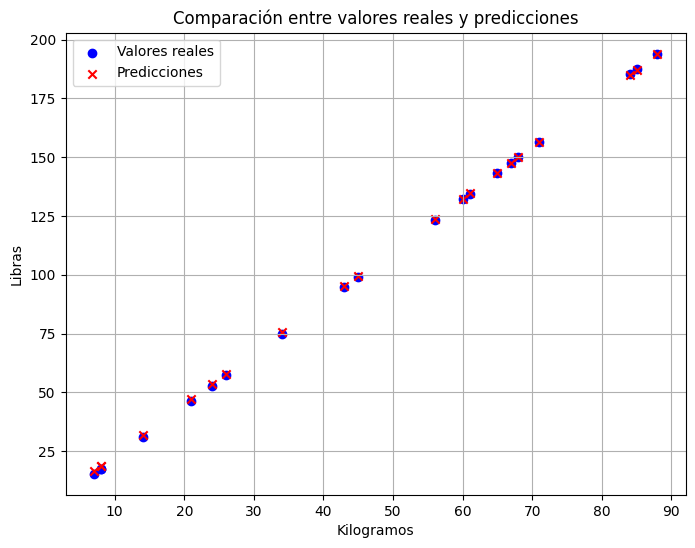

In [85]:
# Crear gráfico de dispersión
plt.figure(figsize=(8,6))
plt.scatter(X_test, Y_test, label="Valores reales", color="blue")
plt.scatter(X_test, predicciones, label="Predicciones", color="red", marker='x')

# Etiquetas y leyenda
plt.xlabel("Kilogramos")
plt.ylabel("Libras")
plt.title("Comparación entre valores reales y predicciones")
plt.legend()
plt.grid()

# Mostrar gráfico
plt.show()